# Notebook 06 — Basel III IRB Capital

## Central Question

**We calibrated a point-in-time PD for IFRS 9 provisioning. Basel IRB capital requires a through-the-cycle PD and a fundamentally different loss concept — unexpected loss at 99.9% confidence. How do we serve both regulatory regimes from one model, and what does the ASRF formula actually do to our PD to produce a stable, downturn-calibrated capital charge?**

## Why It Matters — The Two-Regime Problem

The same PD model feeds two regulatory regimes with opposite requirements. Confusing them is one of the most common errors in credit risk, so we state the distinction precisely before computing anything.

**IFRS 9 provisioning covers expected loss (EL)** — the loss anticipated on average, recognized through the P&L as a provision. It requires **point-in-time (PIT) PD**, reflecting current economic conditions, so that provisions *track the cycle*: they rise in a downturn and fall in a recovery. This is what Notebook 05 computed.

**Basel capital covers unexpected loss (UL)** — the loss *beyond* expected, measured at the 99.9th percentile of the one-year loss distribution, held as regulatory capital. It requires **through-the-cycle (TTC) PD**, a long-run average deliberately *insensitive* to the current cycle position, so that capital is *stable* and does not amplify the cycle.

| | IFRS 9 (Notebook 05) | Basel IRB (this notebook) |
|---|---|---|
| Loss concept | Expected loss (EL) | Unexpected loss (UL) |
| Confidence level | Mean (expected value) | 99.9th percentile |
| Held as | P&L provision | Regulatory capital |
| PD flavor | Point-in-time (PIT) | Through-the-cycle (TTC) |
| Cycle behavior | Tracks the cycle (intended) | Stable across cycle (intended) |
| Same borrower → | cycle-sensitive PD | cycle-stable PD |

The same borrower, the same model, the same underlying default probability — yet provisioning wants the PD to move with the cycle and capital wants it not to. A credit risk function manages both from a single model. **That tension is the subject of this notebook.**

## What This Dataset Supports

As in Notebook 05, the dataset provides PIT PD but no LGD, EAD, maturity, or macroeconomic history. We bridge with stated assumptions:

| Basel input | Source | Treatment |
|---|---|---|
| PD (PIT) | Champion model (Notebook 03) | Used directly as base case |
| PD (TTC) | No cycle history available | Illustrative adjustment in Section 7 (procyclicality demo) |
| LGD | Basel FIRB benchmark | 45% (as Notebook 05) |
| EAD | None | Unit exposure (capital expressed as rate) |
| Maturity (M) | None | Retail treatment (maturity adjustment dropped) |
| Asset correlation (R) | **Basel-prescribed** | Computed exactly from the regulatory retail formula |
| PD floor | Basel-prescribed | 0.03% floor applied |

Note that the asset correlation and PD floor are **regulatory constants**, not estimated quantities — these we implement faithfully. Per the Notebook 05 handoff, the base case computes IRB capital on the PIT PD (honest about the data), and Section 7 demonstrates the PIT→TTC adjustment and the procyclicality it addresses.

## Roadmap

1. Setup and the two-regime framing
2. Expected vs unexpected loss — the loss distribution
3. The PIT→TTC question
4. The ASRF formula, dissected (Vasicek conditional PD, EL subtraction, asset correlation)
5. IRB capital calculation — K, RWA, capital charge
6. Standardised Approach comparison
7. Procyclicality and sensitivity
8. Key finding and handoff to Notebook 07

## 1. Setup and the Two-Regime Framing

We load the champion PIT PD — the same artifact and re-scoring used in Notebook 05 — and fix the Basel-specific parameters. The portfolio frame carries forward unchanged; what changes is the regulatory lens applied to the PD.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm
import joblib

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

# --- Load champion and re-score PIT PD (consistent with Notebook 05) ---
champion = joblib.load('../models/lr_champion.pkl')
model_lr     = champion['model']
logit_offset = champion['logit_offset']

X_test_woe = pd.read_csv('../data/X_test_woe.csv')
y_test     = pd.read_csv('../data/y_test.csv').squeeze()

def apply_prior_correction(p_raw, offset):
    p_clipped = np.clip(p_raw, 1e-15, 1 - 1e-15)
    logit_raw = np.log(p_clipped / (1 - p_clipped))
    return 1 / (1 + np.exp(-(logit_raw + offset)))

pd_pit = apply_prior_correction(model_lr.predict_proba(X_test_woe)[:, 1], logit_offset)

# --- Basel parameters ---
BASEL = {
    'LGD': 0.45,            # FIRB benchmark, as Notebook 05
    'EAD': 1.0,             # unit exposure → capital as a rate
    'confidence': 0.999,    # 99.9% — the IRB capital confidence level
    'pd_floor': 0.0003,     # 0.03% regulatory PD floor
}

# Apply the regulatory PD floor immediately (Basel requires PD >= 0.03%)
pd_pit_floored = np.maximum(pd_pit, BASEL['pd_floor'])
n_floored = (pd_pit < BASEL['pd_floor']).sum()

portfolio = pd.DataFrame({
    'pd_pit': pd_pit_floored,
    'actual_default': y_test.values,
    'EAD': BASEL['EAD'],
})

print(f"Borrowers:                 {len(portfolio):,}")
print(f"Mean PIT PD:               {portfolio['pd_pit'].mean():.4%}")
print(f"Median PIT PD:             {portfolio['pd_pit'].median():.4%}")
print(f"Borrowers below PD floor:  {n_floored:,} (raised to {BASEL['pd_floor']:.2%})")
print(f"\nBasel parameters:")
for k, v in BASEL.items():
    print(f"  {k:12s}: {v}")

Borrowers:                 30,000
Mean PIT PD:               7.0577%
Median PIT PD:             2.2576%
Borrowers below PD floor:  0 (raised to 0.03%)

Basel parameters:
  LGD         : 0.45
  EAD         : 1.0
  confidence  : 0.999
  pd_floor    : 0.0003


## 2. Expected vs Unexpected Loss — The Loss Distribution

Capital exists to absorb the loss that provisions do not. To see why, we look at the full distribution of possible portfolio losses over one year.

### The two quantities, formally

For a single exposure, **expected loss** is the mean of the loss distribution:

$$\text{EL} = \text{PD} \times \text{LGD} \times \text{EAD}$$

This is provisioned under IFRS 9. A bank expects to lose this much on average, prices it into the loan, and reserves for it.

**Unexpected loss** is the variability *around* that mean — the risk that realized losses in a given year exceed the expected. Capital is sized to cover this at a high confidence level. Basel sets the level at **99.9%**: capital must absorb losses up to the level exceeded only once in 1,000 years.

$$\text{Capital} = \text{Loss}_{99.9\%} - \text{EL}$$

Capital covers the gap between the 99.9% worst-case loss and the expected loss. The expected portion is already provisioned; capital covers only the unexpected excess. This subtraction is the formal bridge between the two regimes — and it appears explicitly inside the ASRF formula in Section 4.

### Why losses are not normally distributed

If defaults were independent, portfolio loss would be near-normal by the central limit theorem, and capital would be modest. They are not independent — defaults cluster, because borrowers share exposure to common economic conditions (the systematic risk factor). In a bad year, *many* borrowers default together. This correlation produces a **right-skewed, fat-tailed** loss distribution: most years see losses near the expected level, but occasional years see losses far above it. That fat tail is what drives the 99.9% capital requirement well above expected loss.

We illustrate this with a Monte Carlo simulation of correlated defaults using the single-factor (Vasicek) model that underlies the Basel framework.

In [2]:
def simulate_portfolio_loss(pd_vec, lgd, ead, asset_corr, n_sims=20000, seed=42):
    """
    Single-factor (Vasicek) Monte Carlo of one-year portfolio loss.

    Each borrower i defaults if a latent asset return A_i falls below its
    default threshold N^{-1}(PD_i). Asset returns share a common systematic
    factor M with loading sqrt(rho):
        A_i = sqrt(rho) * M + sqrt(1-rho) * eps_i
    M is the same draw for all borrowers in a given simulated year, inducing
    default correlation. eps_i is idiosyncratic.
    """
    rng = np.random.default_rng(seed)
    N = len(pd_vec)
    thresholds = norm.ppf(pd_vec)                      # (N,)
    sqrt_rho = np.sqrt(asset_corr)
    sqrt_1mrho = np.sqrt(1 - asset_corr)

    losses = np.empty(n_sims)
    # Simulate year by year (vectorized over borrowers)
    for s in range(n_sims):
        M = rng.standard_normal()                       # systematic factor (scalar per year)
        eps = rng.standard_normal(N)                    # idiosyncratic
        A = sqrt_rho * M + sqrt_1mrho * eps
        defaults = A < thresholds
        losses[s] = (defaults * lgd * ead).sum()
    return losses / (ead * N)                           # loss as fraction of exposure

# Use a representative retail asset correlation for the illustration (computed properly in Section 4)
RHO_ILLUSTRATIVE = 0.05

losses = simulate_portfolio_loss(
    portfolio['pd_pit'].values, BASEL['LGD'], BASEL['EAD'],
    asset_corr=RHO_ILLUSTRATIVE, n_sims=20000, seed=RANDOM_STATE
)

el_analytical = portfolio['pd_pit'].mean() * BASEL['LGD']
loss_999 = np.quantile(losses, 0.999)
loss_mean = losses.mean()
capital_999 = loss_999 - loss_mean

print("Monte Carlo portfolio loss distribution (single-factor, illustrative ρ=0.05):\n")
print(f"  Analytical EL (PD×LGD):       {el_analytical:.4%}")
print(f"  Simulated mean loss:          {loss_mean:.4%}")
print(f"  Simulated 99.9% loss:         {loss_999:.4%}")
print(f"  → Unexpected loss (capital):  {capital_999:.4%}")
print(f"  → Capital / EL ratio:         {capital_999/loss_mean:.2f}×")
print(f"\n  Loss distribution shape:")
print(f"    Skewness: {stats.skew(losses):.3f}  (>0 = right tail)")
print(f"    99.9% / mean: {loss_999/loss_mean:.2f}×  (tail extends well beyond the mean)")

Monte Carlo portfolio loss distribution (single-factor, illustrative ρ=0.05):

  Analytical EL (PD×LGD):       3.1760%
  Simulated mean loss:          3.1808%
  Simulated 99.9% loss:         7.2405%
  → Unexpected loss (capital):  4.0597%
  → Capital / EL ratio:         1.28×

  Loss distribution shape:
    Skewness: 0.791  (>0 = right tail)
    99.9% / mean: 2.28×  (tail extends well beyond the mean)


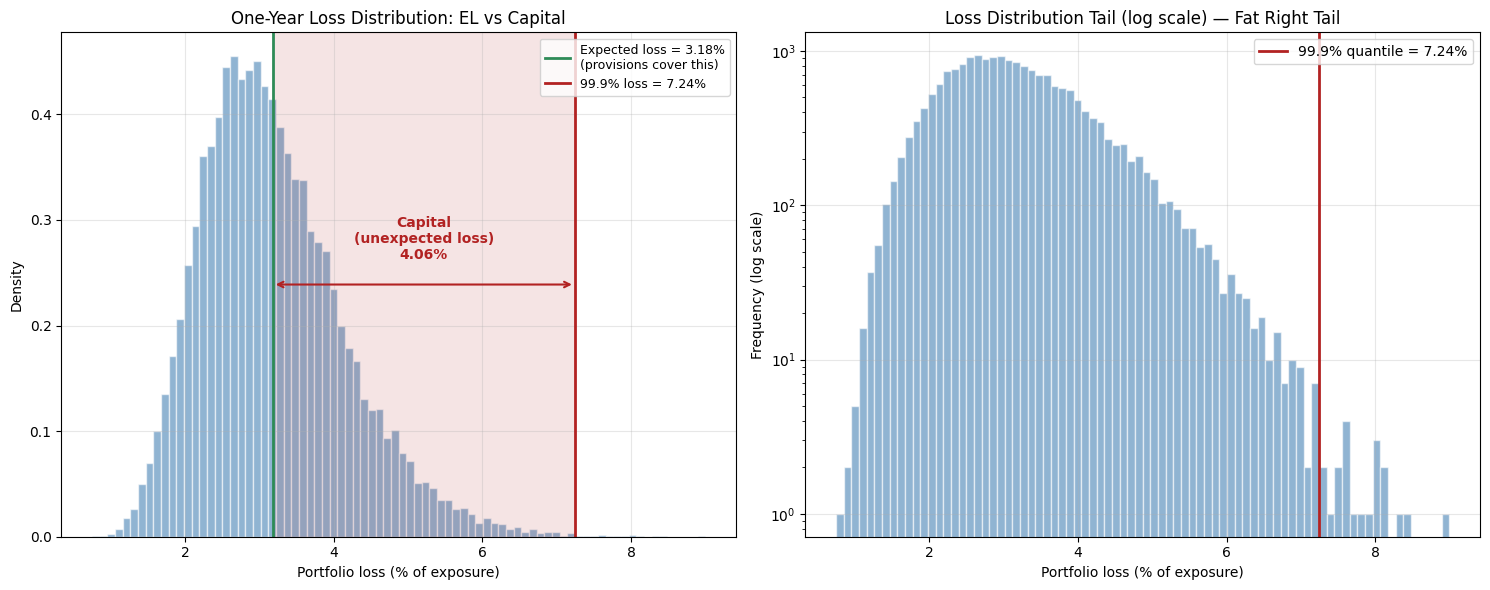

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1: the loss distribution with EL and capital marked
ax = axes[0]
ax.hist(losses * 100, bins=80, color='steelblue', alpha=0.6, edgecolor='white', density=True)
ax.axvline(loss_mean * 100, color='seagreen', linestyle='-', linewidth=2,
           label=f'Expected loss = {loss_mean:.2%}\n(provisions cover this)')
ax.axvline(loss_999 * 100, color='firebrick', linestyle='-', linewidth=2,
           label=f'99.9% loss = {loss_999:.2%}')
ax.axvspan(loss_mean * 100, loss_999 * 100, alpha=0.12, color='firebrick')
ax.annotate('', xy=(loss_999*100, ax.get_ylim()[1]*0.5),
            xytext=(loss_mean*100, ax.get_ylim()[1]*0.5),
            arrowprops=dict(arrowstyle='<->', color='firebrick', lw=1.5))
ax.text((loss_mean+loss_999)/2*100, ax.get_ylim()[1]*0.55,
        f'Capital\n(unexpected loss)\n{capital_999:.2%}',
        ha='center', color='firebrick', fontsize=10, fontweight='bold')
ax.set_xlabel('Portfolio loss (% of exposure)')
ax.set_ylabel('Density')
ax.set_title('One-Year Loss Distribution: EL vs Capital')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)

# Panel 2: the tail, log-scale, to show fatness
ax = axes[1]
ax.hist(losses * 100, bins=80, color='steelblue', alpha=0.6, edgecolor='white')
ax.axvline(loss_999 * 100, color='firebrick', linestyle='-', linewidth=2,
           label=f'99.9% quantile = {loss_999:.2%}')
ax.set_yscale('log')
ax.set_xlabel('Portfolio loss (% of exposure)')
ax.set_ylabel('Frequency (log scale)')
ax.set_title('Loss Distribution Tail (log scale) — Fat Right Tail')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/06_loss_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

**Reading the loss distribution.**

**EL vs capital — the economic case for regulatory capital.** Expected loss is 3.18% 
(provisioned under IFRS 9); the 99.9% loss is 7.24%; capital (unexpected loss) is the 4.06% 
gap between them — a capital/EL ratio of 1.28×. The bank holds about as much capital for the 
unexpected portion as it provisions for the expected. Provisions cover the average year; 
capital covers the 1-in-1000 year, which loses more than double the average. Without capital, 
a single bad year would exceed provisions by 4.06% of exposure.

**The EL subtraction.** Capital = 99.9% loss − EL. The expected portion is already provisioned, 
so capital covers only the unexpected excess. This exact subtraction reappears literally inside 
the ASRF formula (Section 4).

**Simulation validated.** Simulated mean loss (3.1808%) matches the analytical EL (3.1760%) to 
0.5bp — confirming the Monte Carlo is unbiased and licensing trust in its tail.

**The fat tail is correlation-driven, and modest here by design.** Skewness is 0.79 and the 
99.9% loss is 2.28× the mean — a genuine fat right tail (a symmetric distribution would have 
skew 0). The tail is fat because defaults cluster through the shared systematic factor; with 
independent defaults (ρ=0) the distribution would collapse to a thin spike and capital would 
be trivial. The tail is only *moderately* fat here because this uses an illustrative ρ=0.05. 
The Basel retail formula (Section 4) gives a PD-dependent ρ up to 0.16 for low-PD borrowers — 
far higher — which fattens the tail and raises capital. Capital is extraordinarily sensitive 
to ρ, which is why Basel prescribes it rather than allowing bank estimation: discretion over ρ 
would invite systematic under-capitalization.

**The ASRF formula is the closed form of this simulation.** The 99.9% quantile here rests on 
~20 of 20,000 draws and carries Monte Carlo tail noise (visible in the jagged log-scale tail). 
Basel does not require simulation; it provides the analytical 99.9% quantile under this same 
single-factor model. Section 4 is the exact answer this simulation approximates.

**PIT caveat.** This distribution uses PIT PD, reflecting current conditions. Section 7 asks 
what happens to it — and to capital — as the cycle moves, which is the procyclicality question.

## 3. The PIT→TTC Question

Our model produces a point-in-time PD. Basel capital is designed around a through-the-cycle PD. Before applying the ASRF formula, we need to understand what that distinction means, why it exists, and what it costs to ignore it.

### What "point-in-time" and "through-the-cycle" actually mean

Both describe the same borrower's default probability, but they answer different questions.

**Point-in-time (PIT) PD** answers: *given everything we know about this borrower and the current state of the economy, what is the probability they default in the next year?* It rises in recessions and falls in expansions. It is the correct input for IFRS 9, where provisions are meant to reflect current expected losses. Our model, calibrated to the observed default rate in the data (Notebook 03), is a PIT estimate.

**Through-the-cycle (TTC) PD** answers: *what is this borrower's average default probability across a full economic cycle, abstracting away from where we currently sit in that cycle?* It is deliberately stable — it does not move just because the economy moved. It is the intended input for Basel capital.

The relationship, conceptually:

$$\text{PD}_{\text{PIT}}(t) = f\big(\text{PD}_{\text{TTC}},\ \text{cycle position}(t)\big)$$

A TTC PD is roughly the cyclical average of the PIT PD. In a downturn, PIT > TTC; in a boom, PIT < TTC; on average over the cycle, they coincide.

### Why capital wants TTC — the procyclicality problem

This is the heart of the matter, and it is a lesson learned painfully in 2008.

If regulatory capital were driven by PIT PD, then in a downturn — exactly when default probabilities spike — required capital would surge. Banks would face higher capital requirements precisely when capital is hardest and most expensive to raise. To meet the requirement, they would cut lending, which deepens the downturn, which raises PDs further, which raises capital requirements again. This self-reinforcing loop is **procyclicality**, and Basel II's PIT-leaning IRB framework was criticized for amplifying the financial crisis through exactly this mechanism.

TTC PD breaks the loop. A capital requirement built on a cycle-stable PD does not surge in downturns, so it does not force fire-sale deleveraging at the worst moment. Capital becomes a stable buffer rather than a procyclical amplifier.

### How Basel actually achieves cycle-stability

Basel does not rely solely on banks supplying a perfectly TTC PD. The framework builds cycle-robustness in through two mechanisms, both of which we will see in Section 4:

1. **The 99.9% downturn calibration.** The ASRF formula does not use the PD directly as the capital driver — it transforms it into a *conditional* PD: the default rate when the systematic factor is at its 99.9% worst case. This is a stress already baked into the formula. Even a PIT PD, run through this transformation, produces a capital number anchored to a severe scenario rather than to today's conditions.

2. **The asset correlation.** The prescribed ρ controls how much the PD is amplified under stress. Its calibration reflects long-run, downturn-aware supervisory judgment.

In practice, banks are expected to supply PDs that are *at least* not strongly procyclical, and the formula's downturn anchoring does the rest. A fully PIT PD fed into the IRB formula will retain *some* procyclicality (the formula stresses the systematic factor, but the input PD still moves with the cycle); a well-constructed TTC PD removes most of it.

### What this dataset supports

We have no cycle history — a single cross-sectional snapshot cannot reveal where in the cycle it sits, nor can it support estimating a TTC average. We therefore:

- Compute base-case IRB capital on the **PIT PD** (Sections 4–6), honest that this is what the data is, and accepting the residual procyclicality this implies.
- **Demonstrate** an illustrative PIT→TTC adjustment below, to show its direction and effect.
- Use that adjustment in **Section 7** to make the procyclicality problem visible: simulating a cycle and showing how PIT-driven capital swings while TTC-driven capital stays stable.

### An illustrative TTC adjustment

A TTC PD compresses the cyclical variation of the PIT PD toward the long-run mean. With no
cycle data, we cannot estimate the true compression, so we demonstrate the *mechanism* with a
simple variance-compression toward the portfolio's central tendency — explicitly illustrative,
not estimated.

In [4]:
def pit_to_ttc_illustrative(pd_pit, compression=0.5):
    """
    Illustrative PIT->TTC adjustment via log-odds compression toward the
    portfolio mean log-odds.

    compression = 0  -> no change (PD stays fully PIT)
    compression = 1  -> fully compressed to the portfolio mean (maximally TTC)

    This shrinks each borrower's log-odds toward the average, dampening the
    cyclical spread. It is a DEMONSTRATION of direction/effect, not an
    estimated cycle adjustment.
    """
    logit_pit = np.log(pd_pit / (1 - pd_pit))
    logit_mean = logit_pit.mean()
    logit_ttc = logit_mean + (1 - compression) * (logit_pit - logit_mean)
    return 1 / (1 + np.exp(-logit_ttc))

pd_ttc_illus = pit_to_ttc_illustrative(portfolio['pd_pit'].values, compression=0.5)

print("Illustrative PIT vs TTC PD (compression = 0.5):\n")
comp = pd.DataFrame({
    'statistic': ['mean', 'median', '5th pctile', '95th pctile', 'std of log-odds'],
    'PIT PD': [
        portfolio['pd_pit'].mean(),
        np.median(portfolio['pd_pit']),
        np.percentile(portfolio['pd_pit'], 5),
        np.percentile(portfolio['pd_pit'], 95),
        np.std(np.log(portfolio['pd_pit'] / (1 - portfolio['pd_pit']))),
    ],
    'TTC PD (illus.)': [
        pd_ttc_illus.mean(),
        np.median(pd_ttc_illus),
        np.percentile(pd_ttc_illus, 5),
        np.percentile(pd_ttc_illus, 95),
        np.std(np.log(pd_ttc_illus / (1 - pd_ttc_illus))),
    ],
})
for c in ['PIT PD', 'TTC PD (illus.)']:
    comp[c] = comp[c].apply(lambda x: f"{x:.4%}" if abs(x) < 5 else f"{x:.4f}")
print(comp.to_string(index=False))

print("\n  Note: TTC compresses the spread (lower 95th pctile, higher 5th pctile,")
print("  smaller log-odds std) while broadly preserving the central tendency.")
print("  The mean PD shifts slightly because PD is non-linear in log-odds.")

Illustrative PIT vs TTC PD (compression = 0.5):

      statistic    PIT PD TTC PD (illus.)
           mean   7.0577%         4.1083%
         median   2.2576%         2.6949%
     5th pctile   0.7738%         1.5838%
    95th pctile  33.8826%        11.5402%
std of log-odds 133.8089%        66.9044%

  Note: TTC compresses the spread (lower 95th pctile, higher 5th pctile,
  smaller log-odds std) while broadly preserving the central tendency.
  The mean PD shifts slightly because PD is non-linear in log-odds.


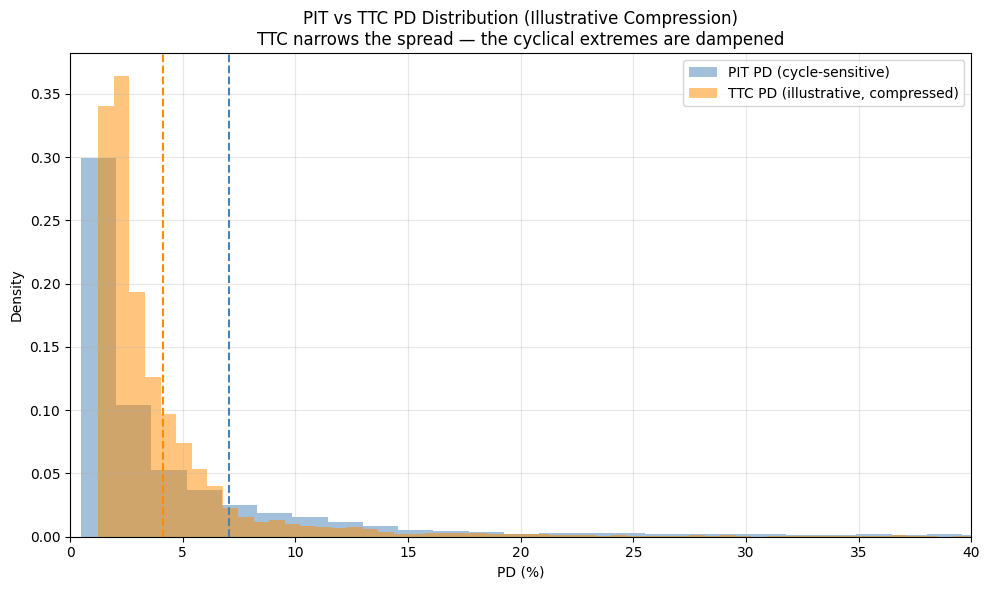

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(portfolio['pd_pit'].values * 100, bins=60, alpha=0.5, color='steelblue',
        label='PIT PD (cycle-sensitive)', density=True)
ax.hist(pd_ttc_illus * 100, bins=60, alpha=0.5, color='darkorange',
        label='TTC PD (illustrative, compressed)', density=True)
ax.axvline(portfolio['pd_pit'].mean() * 100, color='steelblue', linestyle='--', linewidth=1.5)
ax.axvline(pd_ttc_illus.mean() * 100, color='darkorange', linestyle='--', linewidth=1.5)
ax.set_xlabel('PD (%)')
ax.set_ylabel('Density')
ax.set_xlim(0, 40)
ax.set_title('PIT vs TTC PD Distribution (Illustrative Compression)\n'
             'TTC narrows the spread — the cyclical extremes are dampened')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/06_pit_vs_ttc.png', dpi=120, bbox_inches='tight')
plt.show()

**Reading the PIT→TTC adjustment.**

**Spread compression (verified).** The log-odds standard deviation halved exactly (133.8% → 
66.9%), as compression=0.5 requires. The 95th-percentile PD collapsed from 33.9% to 11.5% and 
the 5th percentile rose from 0.77% to 1.58%, while the median barely moved (2.26% → 2.69%). 
The cyclical extremes are pulled toward the center; the typical borrower is largely unchanged. 
This is the defining shape property of a TTC PD: narrower cyclical spread than PIT.

**The mean shift is large, and it is the key lesson.** Mean PD fell from 7.06% to 4.11% — a 
42% reduction, far from negligible. The cause is the sigmoid's convexity: the mean PIT PD is 
dominated by a fat high-PD tail sitting in the steep region of the sigmoid, where compressing 
log-odds inward produces large PD reductions (a 34% borrower drops toward 11.5%), while low-PD 
borrowers in the flat region barely rise. Compressing log-odds is therefore NOT mean-preserving 
in PD space, and the gap is largest precisely when the PD distribution has a fat high tail — as 
this high-default cross-section does.

**Re-centering — a real TTC design choice.** A properly estimated TTC PD has its mean equal to 
the long-run observed average default rate, since "through the cycle" means the cyclical 
average. An illustrative compression that drops the mean to 4.11% would, in production, be 
re-anchored to match that long-run rate. Our demonstration shows the *shape* effect without 
re-anchoring — adequate for illustration, but a real calibration would re-center the mean.

**Honesty restatement.** Compression=0.5 is arbitrary; a real TTC adjustment is estimated from 
multi-year through-the-cycle default history the dataset lacks. The contribution is the 
direction (spread compression) and the demonstration that the transformation is non-linear in 
PD — setting up Section 7.

**Why this matters for capital.** The PIT and TTC distributions now differ in both spread and 
mean. Run through the convex ASRF formula (Sections 4–7), they will produce substantially and 
non-linearly different capital, because the high-PD borrowers most affected by compression also 
drive capital most. This is the mechanism behind the procyclicality demonstration in Section 7: 
PIT capital swings with the cycle, TTC capital holds.

## 4. The ASRF Formula, Dissected

The Basel IRB capital requirement is not an arbitrary formula — it is the closed-form solution to the single-factor (Vasicek) credit risk model we simulated in Section 2. Here we derive what it does, piece by piece, then compute it properly with the Basel-prescribed retail asset correlation.

### The model underneath: a single systematic factor

Each borrower $i$ has a latent "asset value" $A_i$ that determines default — the borrower defaults if $A_i$ falls below a threshold. Basel assumes $A_i$ is driven by one systematic factor $M$ (the economy) plus idiosyncratic noise $\varepsilon_i$:

$$A_i = \sqrt{\rho}\, M + \sqrt{1-\rho}\, \varepsilon_i$$

where $M, \varepsilon_i \sim N(0,1)$ are independent, and $\rho$ is the **asset correlation** — the weight on the common factor. A borrower defaults when $A_i < N^{-1}(\text{PD}_i)$, which reproduces the unconditional default probability $\text{PD}_i$ by construction.

This is exactly the data-generating process of the Section 2 Monte Carlo. The ASRF formula is its analytical 99.9% loss quantile — no simulation needed.

### The Vasicek conditional PD — the core of the formula

The key question for capital: *what is the default rate when the economy is at its 99.9% worst?* We condition on a severe value of the systematic factor. A bad economy is a low $M$; the 99.9% worst case sets $M = N^{-1}(0.001) = -N^{-1}(0.999)$.

Conditional on $M$, borrower $i$ defaults when $\varepsilon_i < \frac{N^{-1}(\text{PD}_i) - \sqrt{\rho} M}{\sqrt{1-\rho}}$. Taking the probability and substituting the stressed $M$:

$$\text{PD}_{\text{conditional}} = N\!\left( \frac{N^{-1}(\text{PD}) + \sqrt{\rho}\, N^{-1}(0.999)}{\sqrt{1-\rho}} \right)$$

This is the heart of the formula. It transforms the *average* PD into the *stressed* PD — the default rate in a 1-in-1000 year. Three things to read in it:

- $N^{-1}(\text{PD})$ is the borrower's default threshold on the latent scale.
- $\sqrt{\rho}\, N^{-1}(0.999)$ is the **stress**: the systematic factor pushed to its 99.9% adverse value, scaled by how exposed the borrower is to it ($\sqrt{\rho}$).
- Dividing by $\sqrt{1-\rho}$ rescales to the conditional distribution.

Higher $\rho$ → more weight on the systematic factor → larger stress amplification → higher conditional PD → more capital. This is why $\rho$ drives everything, as we saw in the Section 2 tail behavior.

### Subtracting expected loss — the link to IFRS 9

The conditional loss is $\text{LGD} \times \text{PD}_{\text{conditional}}$. But capital covers only *unexpected* loss — the expected part ($\text{PD} \times \text{LGD}$) is already provisioned under IFRS 9. So we subtract it:

$$K = \text{LGD} \times \left[ N\!\left( \frac{N^{-1}(\text{PD}) + \sqrt{\rho}\, N^{-1}(0.999)}{\sqrt{1-\rho}} \right) - \text{PD} \right]$$

This is the capital requirement per unit of exposure (before the maturity adjustment). The subtraction is the exact "capital = stressed loss − expected loss" relationship made visible in the Section 2 loss distribution.

### The Basel-prescribed retail asset correlation

For "other retail" exposures, Basel does not let the bank choose $\rho$ — it prescribes a **PD-dependent** formula:

$$\rho = 0.03 \times \frac{1 - e^{-35\,\text{PD}}}{1 - e^{-35}} + 0.16 \times \left(1 - \frac{1 - e^{-35\,\text{PD}}}{1 - e^{-35}}\right)$$

The correlation interpolates between **0.16 (low PD)** and **0.03 (high PD)** as PD rises. The economic logic: low-PD borrowers default mainly when the *whole economy* turns down (high systematic correlation), whereas high-PD borrowers default for idiosyncratic, borrower-specific reasons (low systematic correlation). The decay rate of 35 controls how fast correlation falls with PD. This is a downturn-aware supervisory calibration, not an empirical fit to any single bank's data — which is precisely why it is mandated rather than estimated.

### Maturity adjustment

The full corporate formula includes a maturity adjustment scaling capital up for longer exposures. For **retail exposures, Basel drops the maturity adjustment entirely** — retail capital uses only the terms above. Since this is a retail portfolio, we omit it, and note that this is the regulatory treatment, not a simplification on our part.

### Risk-weighted assets

Finally, capital $K$ is converted to risk-weighted assets via the regulatory multiplier of 12.5 (the reciprocal of the 8% minimum capital ratio):

$$\text{RWA} = K \times 12.5 \times \text{EAD}, \qquad \text{Capital required} = K \times \text{EAD} = \text{RWA} \times 8\%$$

In [6]:
def basel_retail_correlation(pd_vec):
    """
    Basel 'other retail' asset correlation: PD-dependent, interpolating
    between 0.16 (low PD) and 0.03 (high PD).
    """
    pd_vec = np.asarray(pd_vec)
    term = (1 - np.exp(-35 * pd_vec)) / (1 - np.exp(-35))
    rho = 0.03 * term + 0.16 * (1 - term)
    return rho

# Compute rho across the portfolio
portfolio['rho'] = basel_retail_correlation(portfolio['pd_pit'].values)

# Show how rho varies with PD
pd_grid = np.array([0.0003, 0.005, 0.01, 0.02, 0.05, 0.10, 0.20, 0.50, 0.90])
rho_grid = basel_retail_correlation(pd_grid)
print("Basel 'other retail' asset correlation by PD:\n")
rho_table = pd.DataFrame({
    'PD': [f"{p:.2%}" for p in pd_grid],
    'rho': [f"{r:.4f}" for r in rho_grid],
})
print(rho_table.to_string(index=False))

print(f"\nPortfolio rho: min {portfolio['rho'].min():.4f}, "
      f"max {portfolio['rho'].max():.4f}, "
      f"mean {portfolio['rho'].mean():.4f}")
print(f"(Recall Section 2 used an illustrative flat rho=0.05 — the real formula")
print(f" gives higher rho for the low-PD majority, hence more capital.)")

Basel 'other retail' asset correlation by PD:

    PD    rho
 0.03% 0.1586
 0.50% 0.1391
 1.00% 0.1216
 2.00% 0.0946
 5.00% 0.0526
10.00% 0.0339
20.00% 0.0301
50.00% 0.0300
90.00% 0.0300

Portfolio rho: min 0.0300, max 0.1396, mean 0.0822
(Recall Section 2 used an illustrative flat rho=0.05 — the real formula
 gives higher rho for the low-PD majority, hence more capital.)


In [7]:
def asrf_capital(pd_vec, lgd, rho_vec=None, confidence=0.999):
    """
    Basel IRB capital per unit EAD for retail exposures (no maturity adjustment).

    K = LGD * [ N( (N^{-1}(PD) + sqrt(rho)*N^{-1}(0.999)) / sqrt(1-rho) ) - PD ]
    """
    pd_vec = np.asarray(pd_vec)
    if rho_vec is None:
        rho_vec = basel_retail_correlation(pd_vec)

    stress = norm.ppf(confidence)                      # N^{-1}(0.999)
    conditional_pd = norm.cdf(
        (norm.ppf(pd_vec) + np.sqrt(rho_vec) * stress) / np.sqrt(1 - rho_vec)
    )
    K = lgd * (conditional_pd - pd_vec)
    return K, conditional_pd

K, conditional_pd = asrf_capital(
    portfolio['pd_pit'].values, BASEL['LGD'], portfolio['rho'].values, BASEL['confidence']
)
portfolio['conditional_pd'] = conditional_pd
portfolio['K'] = K
portfolio['RWA'] = portfolio['K'] * 12.5 * portfolio['EAD']
portfolio['EL'] = portfolio['pd_pit'] * BASEL['LGD'] * portfolio['EAD']

# Illustrate the PD -> conditional PD stress for representative borrowers
print("The Vasicek stress transformation (PD → conditional PD at 99.9%):\n")
ex_pds = [0.0077, 0.0226, 0.3388]   # 5th pctile, median, 95th pctile from earlier
ex_labels = ['Low (5th pctile)', 'Median', 'High (95th pctile)']
for label, p in zip(ex_labels, ex_pds):
    r = basel_retail_correlation(np.array([p]))[0]
    Kx, cpd = asrf_capital(np.array([p]), BASEL['LGD'], np.array([r]))
    print(f"{label}: PD={p:.2%}")
    print(f"   rho={r:.4f} | conditional PD={cpd[0]:.2%} "
          f"(stress factor {cpd[0]/p:.1f}×) | K={Kx[0]:.4%} | "
          f"RWA={Kx[0]*12.5:.2%}\n")

The Vasicek stress transformation (PD → conditional PD at 99.9%):

Low (5th pctile): PD=0.77%
   rho=0.1293 | conditional PD=7.99% (stress factor 10.4×) | K=3.2493% | RWA=40.62%

Median: PD=2.26%
   rho=0.0889 | conditional PD=12.87% (stress factor 5.7×) | K=4.7728% | RWA=59.66%

High (95th pctile): PD=33.88%
   rho=0.0300 | conditional PD=54.83% (stress factor 1.6×) | K=9.4271% | RWA=117.84%



### Validation: the formula is the closed form of the simulation

To confirm the ASRF formula is the analytical answer to the Section 2 Monte Carlo, we run the
single-factor simulation again with a FIXED rho, and compare the simulated 99.9% loss against
the analytical conditional-loss the formula produces at the same rho. They should match (up to
Monte Carlo noise).

In [8]:
# Use a single fixed rho so simulation and formula are directly comparable
rho_test = 0.10

# Analytical: portfolio conditional loss at 99.9% under fixed rho
K_test, cond_pd_test = asrf_capital(portfolio['pd_pit'].values, BASEL['LGD'],
                                    np.full(len(portfolio), rho_test), 0.999)
analytical_999_loss = (cond_pd_test * BASEL['LGD']).mean()   # conditional EL = stressed loss
analytical_el = portfolio['EL'].mean()
analytical_capital = analytical_999_loss - analytical_el

# Simulation: re-run Section 2 MC at the same fixed rho
sim_losses = simulate_portfolio_loss(
    portfolio['pd_pit'].values, BASEL['LGD'], BASEL['EAD'],
    asset_corr=rho_test, n_sims=20000, seed=RANDOM_STATE
)
sim_999_loss = np.quantile(sim_losses, 0.999)

print(f"Formula vs simulation at fixed rho={rho_test} (99.9% portfolio loss):\n")
print(f"  Analytical 99.9% loss (ASRF):   {analytical_999_loss:.4%}")
print(f"  Simulated 99.9% loss (MC):      {sim_999_loss:.4%}")
print(f"  Difference:                     {abs(analytical_999_loss - sim_999_loss):.4%}")
print(f"\n  → The ASRF formula reproduces the simulated tail loss analytically,")
print(f"    confirming it is the closed-form 99.9% quantile of the single-factor model.")
print(f"\n  (Small residual is Monte Carlo noise in the tail + the ASRF asymptotic")
print(f"   assumption of an infinitely granular portfolio; our 30k loans approximate this.)")

Formula vs simulation at fixed rho=0.1 (99.9% portfolio loss):

  Analytical 99.9% loss (ASRF):   9.9924%
  Simulated 99.9% loss (MC):      9.8011%
  Difference:                     0.1914%

  → The ASRF formula reproduces the simulated tail loss analytically,
    confirming it is the closed-form 99.9% quantile of the single-factor model.

  (Small residual is Monte Carlo noise in the tail + the ASRF asymptotic
   assumption of an infinitely granular portfolio; our 30k loans approximate this.)


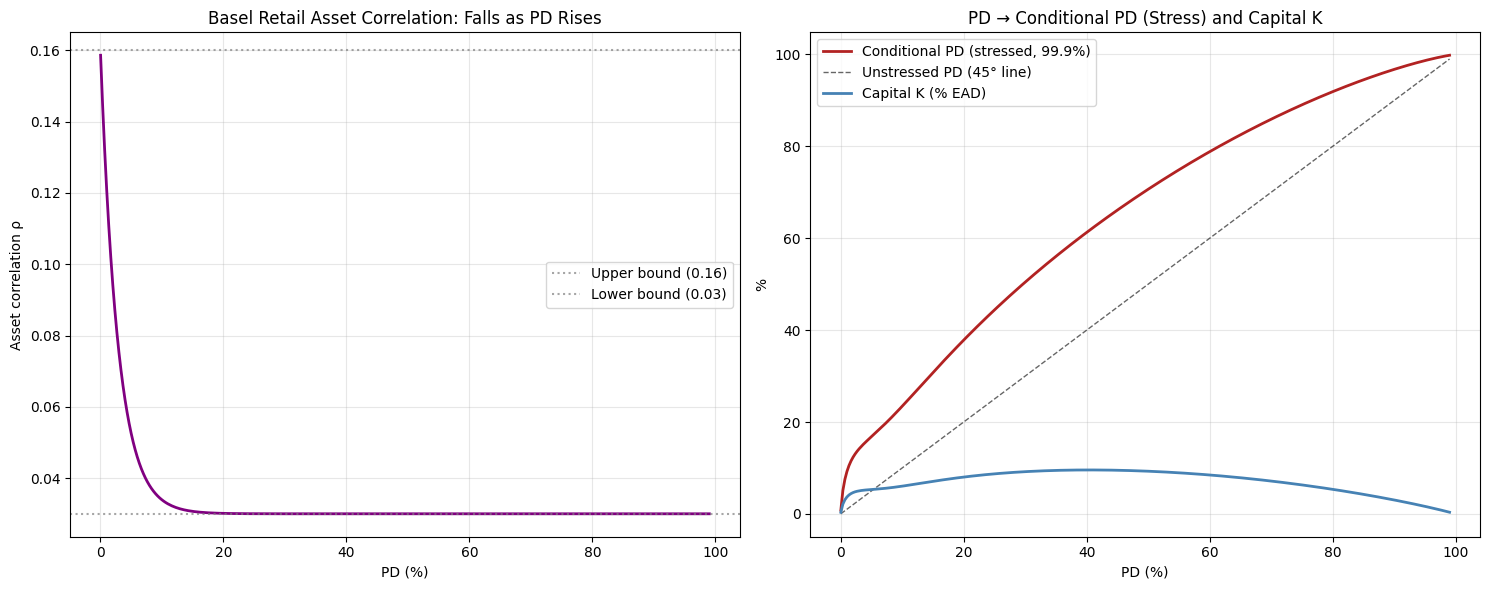

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1: asset correlation vs PD
ax = axes[0]
pd_fine = np.linspace(0.0003, 0.99, 300)
ax.plot(pd_fine * 100, basel_retail_correlation(pd_fine), color='purple', linewidth=2)
ax.axhline(0.16, color='gray', linestyle=':', alpha=0.7, label='Upper bound (0.16)')
ax.axhline(0.03, color='gray', linestyle=':', alpha=0.7, label='Lower bound (0.03)')
ax.set_xlabel('PD (%)')
ax.set_ylabel('Asset correlation ρ')
ax.set_title('Basel Retail Asset Correlation: Falls as PD Rises')
ax.legend()
ax.grid(alpha=0.3)

# Panel 2: PD vs conditional PD and capital K
ax = axes[1]
rho_fine = basel_retail_correlation(pd_fine)
K_fine, cond_fine = asrf_capital(pd_fine, BASEL['LGD'], rho_fine)
ax.plot(pd_fine * 100, cond_fine * 100, color='firebrick', linewidth=2,
        label='Conditional PD (stressed, 99.9%)')
ax.plot(pd_fine * 100, pd_fine * 100, 'k--', linewidth=1, alpha=0.6,
        label='Unstressed PD (45° line)')
ax.plot(pd_fine * 100, K_fine * 100, color='steelblue', linewidth=2,
        label='Capital K (% EAD)')
ax.set_xlabel('PD (%)')
ax.set_ylabel('%')
ax.set_title('PD → Conditional PD (Stress) and Capital K')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/06_asrf_formula.png', dpi=120, bbox_inches='tight')
plt.show()

**Reading the ASRF formula.**

**Formula validated against simulation.** At fixed ρ=0.10, the analytical 99.9% loss (9.99%) 
matches the Monte Carlo (9.80%) within 0.19pp. The ASRF formula is confirmed as the closed-form 
99.9% quantile of the single-factor model simulated in Section 2 — not a regulatory black box. 
The residual is Monte Carlo tail noise plus the ASRF infinite-granularity assumption, which our 
30k finite exposures approximate closely.

**The stress-factor inversion — capital is priced against systematic risk.** The conditional-PD 
stress factor FALLS as PD rises: 10.4× for the low-PD borrower (0.77%), 5.7× at the median, 1.6× 
for the high-PD borrower (33.9%). This is driven entirely by ρ. The low-PD borrower carries 
ρ=0.13 — their default is highly systematic, so a 99.9% bad economy multiplies their rate 
tenfold. The high-PD borrower carries ρ=0.03 — their default is idiosyncratic, so economy-wide 
stress barely moves it. The Basel design judgment: a safe borrower's risk is mostly "will the 
economy turn," a risky borrower's is mostly "this person is in trouble," and only the former 
demands system-wide capital. This is the core economic insight of IRB.

**Absolute capital rises with PD despite the falling stress factor.** K increases 3.25% → 4.77% 
→ 9.43% across the three borrowers, because the high-PD borrower's higher base dominates its 
smaller multiplier (1.6× on 33.9% still exceeds 10.4× on 0.77%). Stress factor and absolute 
capital move in opposite directions with PD — the former driven by ρ, the latter by the base 
level.

**The capital curve is hump-shaped.** K rises with PD, peaks near 9.5% around PD≈40%, then 
declines toward zero as PD→100%. A near-certain default carries almost no UNEXPECTED loss — it 
is already expected — so K = LGD×(conditional PD − PD) → 0. Capital covers surprise; a certain 
default holds no surprise. This non-monotonic capital-vs-PD relationship is a genuine and 
non-obvious property of the formula.

**ρ design confirmed; Section 2 caveat paid off.** ρ runs 0.159 (at the 0.03% floor) to a flat 
0.030 (above ~20% PD), hitting the prescribed bounds. Portfolio mean ρ is 0.082 — well above the 
illustrative flat 0.05 of Section 2 — because the low-PD majority (median 2.26%) sits where ρ is 
high. Portfolio capital in Section 5 will therefore exceed the Section 2 intuition-builder.

## 5. IRB Capital Calculation

We now apply the ASRF formula across the entire portfolio and aggregate to the regulatory totals. The per-borrower quantities (ρ, conditional PD, K, RWA, EL) were computed in Section 4; here we sum them into the portfolio capital requirement and decompose it by risk band to see where capital concentrates.

### The regulatory aggregates

For each borrower, capital per unit exposure is $K_i$, and risk-weighted assets are $\text{RWA}_i = K_i \times 12.5 \times \text{EAD}_i$. The portfolio totals are:

$$\text{RWA}_{\text{total}} = \sum_i \text{RWA}_i, \qquad \text{Capital required} = \sum_i K_i \times \text{EAD}_i = \text{RWA}_{\text{total}} \times 8\%$$

The **risk weight** for an exposure is $\text{RW}_i = K_i \times 12.5$ — the percentage of exposure that counts as risk-weighted. Expressed this way, IRB risk weights are directly comparable to the flat risk weights of the Standardised Approach (Section 6).

Because we use unit exposure (EAD = 1), all aggregates are expressed as fractions of total exposure: the portfolio capital charge is a coverage rate, and the average risk weight is the exposure-weighted mean of the per-borrower risk weights.

In [14]:
# Per-borrower risk weight
portfolio['risk_weight'] = portfolio['K'] * 12.5

# Portfolio aggregates
total_ead       = portfolio['EAD'].sum()
total_rwa       = portfolio['RWA'].sum()
total_capital   = (portfolio['K'] * portfolio['EAD']).sum()
total_el        = (portfolio['EL']).sum()
avg_risk_weight = total_rwa / total_ead
capital_rate    = total_capital / total_ead
rw_desc = portfolio['risk_weight'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])


print("Portfolio IRB capital aggregates (PIT PD base case):\n")
print(f"  Total exposure (EAD):       {total_ead:,.0f} (unit exposures)")
print(f"  Total RWA:                  {total_rwa:,.1f}")
print(f"  Average risk weight:        {avg_risk_weight:.2%}")
print(f"  Total capital required (8%): {total_capital:.4f}  → {capital_rate:.4%} of EAD")
print(f"  Total expected loss (prov.): {total_el:.4f}  → {total_el/total_ead:.4%} of EAD")
print()
print(f"  Capital (UL) / Provisions (EL) ratio: {total_capital/total_el:.2f}×")
print(f"  Total loss-absorbing resources (EL+UL): {(total_capital+total_el)/total_ead:.4%} of EAD")
print()
print("Per-borrower risk weight distribution:")
print(f"count: {rw_desc['count']:.0f}")
print(rw_desc.drop('count').apply(lambda x: f"{x:.2%}").to_string())

Portfolio IRB capital aggregates (PIT PD base case):

  Total exposure (EAD):       30,000 (unit exposures)
  Total RWA:                  18,585.6
  Average risk weight:        61.95%
  Total capital required (8%): 1486.8482  → 4.9562% of EAD
  Total expected loss (prov.): 952.7959  → 3.1760% of EAD

  Capital (UL) / Provisions (EL) ratio: 1.56×
  Total loss-absorbing resources (EL+UL): 8.1321% of EAD

Per-borrower risk weight distribution:
count: 30000
mean     61.95%
std      18.15%
min      23.02%
5%       40.55%
25%      49.40%
50%      59.35%
75%      67.53%
95%     106.47%
max     119.62%


In [11]:
# Risk bands on PIT PD
pd_bands = [0, 0.01, 0.02, 0.05, 0.10, 0.20, 1.01]
band_labels = ['<1%', '1-2%', '2-5%', '5-10%', '10-20%', '>20%']
portfolio['pd_band'] = pd.cut(portfolio['pd_pit'], bins=pd_bands, labels=band_labels, right=False)

band_summary = portfolio.groupby('pd_band', observed=True).agg(
    n=('pd_pit', 'size'),
    mean_pd=('pd_pit', 'mean'),
    mean_rho=('rho', 'mean'),
    mean_risk_weight=('risk_weight', 'mean'),
    total_rwa=('RWA', 'sum'),
    total_capital=('K', 'sum'),
).reset_index()

band_summary['pct_of_book'] = band_summary['n'] / len(portfolio) * 100
band_summary['pct_of_rwa'] = band_summary['total_rwa'] / total_rwa * 100
band_summary['pct_of_capital'] = band_summary['total_capital'] / total_capital * 100

disp = band_summary.copy()
disp['mean_pd'] = (disp['mean_pd'] * 100).round(2)
disp['mean_rho'] = disp['mean_rho'].round(3)
disp['mean_risk_weight'] = (disp['mean_risk_weight'] * 100).round(1)
for c in ['pct_of_book', 'pct_of_rwa', 'pct_of_capital']:
    disp[c] = disp[c].round(1)
disp = disp.rename(columns={
    'pd_band': 'PD band', 'n': 'N', 'mean_pd': 'Mean PD (%)',
    'mean_rho': 'Mean ρ', 'mean_risk_weight': 'Mean RW (%)',
    'pct_of_book': '% book', 'pct_of_rwa': '% RWA', 'pct_of_capital': '% capital',
})
disp = disp.drop(columns=['total_rwa', 'total_capital'])

print("IRB capital by PD band:\n")
print(disp.to_string(index=False))

IRB capital by PD band:

PD band    N  Mean PD (%)  Mean ρ  Mean RW (%)  % book  % RWA  % capital
    <1% 4760         0.82   0.128         41.6    15.9   10.6       10.6
   1-2% 9000         1.43   0.109         52.0    30.0   25.2       25.2
   2-5% 7423         3.14   0.075         62.5    24.7   25.0       25.0
  5-10% 4085         7.08   0.042         69.7    13.6   15.3       15.3
 10-20% 2258        13.42   0.032         84.3     7.5   10.2       10.2
   >20% 2474        45.44   0.030        102.5     8.2   13.6       13.6


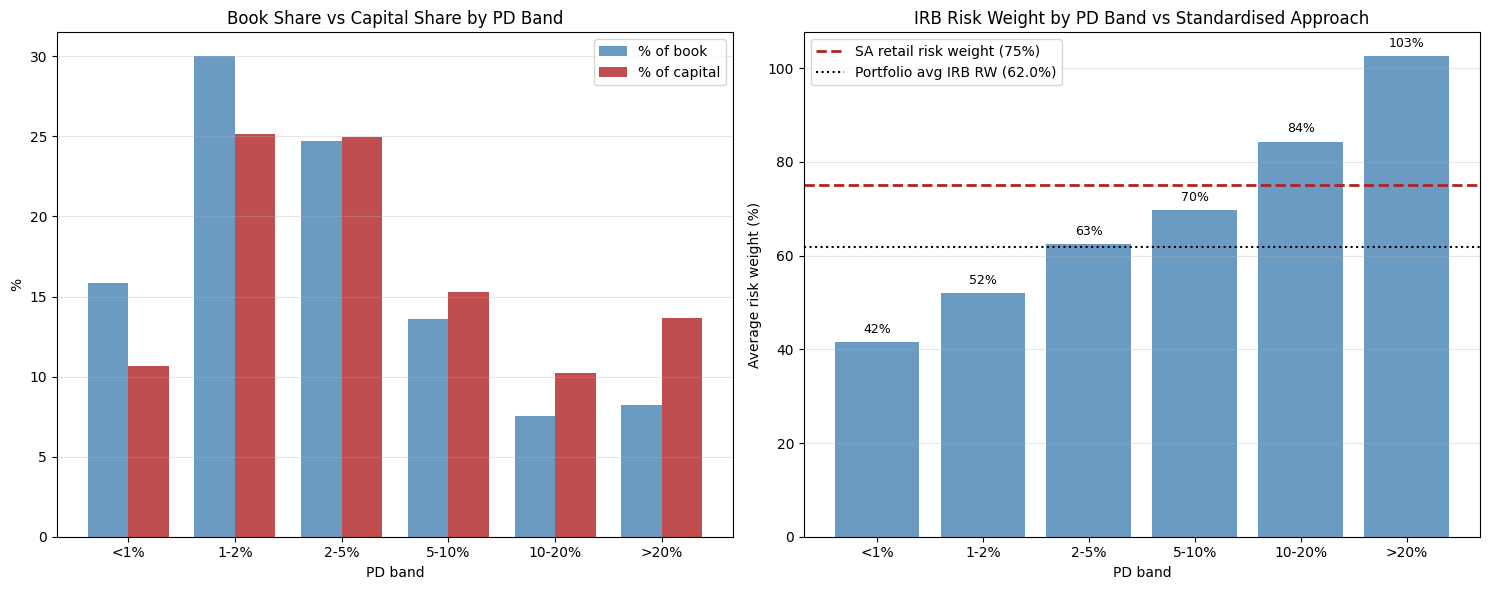

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1: book share vs capital share by band
ax = axes[0]
x = np.arange(len(band_summary))
w = 0.38
ax.bar(x - w/2, band_summary['pct_of_book'], w, label='% of book', color='steelblue', alpha=0.8)
ax.bar(x + w/2, band_summary['pct_of_capital'], w, label='% of capital', color='firebrick', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(band_summary['pd_band'])
ax.set_xlabel('PD band')
ax.set_ylabel('%')
ax.set_title('Book Share vs Capital Share by PD Band')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Panel 2: average risk weight by band, with SA reference line
ax = axes[1]
bars = ax.bar(band_summary['pd_band'].astype(str), band_summary['mean_risk_weight'] * 100,
              color='steelblue', alpha=0.8)
ax.axhline(75, color='firebrick', linestyle='--', linewidth=2,
           label='SA retail risk weight (75%)')
ax.axhline(avg_risk_weight * 100, color='black', linestyle=':', linewidth=1.5,
           label=f'Portfolio avg IRB RW ({avg_risk_weight:.1%})')
ax.set_xlabel('PD band')
ax.set_ylabel('Average risk weight (%)')
ax.set_title('IRB Risk Weight by PD Band vs Standardised Approach')
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)
for b, v in zip(bars, band_summary['mean_risk_weight'] * 100):
    ax.text(b.get_x() + b.get_width()/2, v + 2, f'{v:.0f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/06_capital_by_band.png', dpi=120, bbox_inches='tight')
plt.show()

**Reading the portfolio capital calculation.**

**Average IRB risk weight: 62% vs SA 75%.** At the portfolio level IRB charges less than the 
Standardised Approach's flat 75% retail weight — IRB saves capital for this book. But the margin 
is modest because of the high-default composition. The risk-weight curve crosses the 75% SA line 
between the 5-10% and 10-20% PD bands: the 84% of the book below that crossover is charged less 
than the SA, while the 16% above it (10-20% and >20% bands) is charged more, with the >20% band 
at a 102% risk weight. The 62% average is a blend of the two. A cleaner book would save far more 
under IRB; a riskier one could flip above the SA. This portfolio sits in the zone where IRB and 
SA are comparable.

**The economic content: IRB is risk-sensitive, SA is risk-blind.** The SA charges 75% for every 
retail loan regardless of quality. IRB charges 42% for the safest band and 102% for the riskiest 
— pricing each borrower's actual systematic risk. The SA over-charges good borrowers and 
under-charges bad ones; IRB corrects both. This is the incentive structure behind IRB adoption 
and the substance of the Section 6 comparison.

**The hump shows through partially.** Mean risk weight rises monotonically across all six bands 
(42→52→63→70→84→102%), so it does not turn down at the band level. But it decelerates: the >20% 
band has 3.4× the PD of the 10-20% band yet only 1.2× the risk weight, because its average PD 
(45.4%) sits near the peak of the Section 4 capital curve rather than past it. A band 
concentrated above ~60% PD would show an outright lower risk weight — the hump — but the wide 
>20% band averages across the peak, blunting the effect.

**EL + UL closes the two-regime loop.** Provisions (EL) cover 3.18% of exposure; capital (UL) 
covers 4.96%; together 8.13%, a UL/EL ratio of 1.56×. This is the analytical 99.9% loss under 
the real portfolio correlations (mean ρ=0.082, higher than Section 2's illustrative 0.05, hence 
above the 7.24% simulated there). Provisions and capital are two slices of one loss distribution, 
divided at the expected-loss line: provisions cover up to the mean, capital covers the mean to 
the 99.9% quantile, together covering a 1-in-1000 year. This is the synthesis of the IFRS 9 + 
Basel pairing.

## 6. Standardised Approach Comparison

The IRB approach we just computed is one of two ways a bank can calculate credit risk capital under Basel. The alternative — the **Standardised Approach (SA)** — uses regulator-set risk weights by exposure class, with no internal model. Comparing the two reveals what a bank gains (and pays for) by building an IRB model.

### The Standardised Approach for retail

Under the SA, qualifying retail exposures receive a **flat 75% risk weight** regardless of the individual borrower's PD. (Residential mortgages get lower weights; past-due exposures get higher weights; we use the 75% regulatory retail weight as the comparison point.) The SA capital is simply:

$$\text{Capital}_{\text{SA}} = 75\% \times 8\% \times \text{EAD} = 6\% \times \text{EAD}$$

Every retail loan, prime or subprime, carries the same 6% capital charge under the SA. The approach is deliberately simple and risk-insensitive — it requires no model, no PD estimation, no validation infrastructure.

### What the comparison reveals

IRB and SA answer the same regulatory question (how much capital?) with opposite philosophies:

- **SA is risk-blind.** One weight for all retail, so it over-charges good borrowers and under-charges bad ones relative to their actual risk.
- **IRB is risk-sensitive.** Capital tracks each borrower's PD and systematic risk, so good borrowers are charged less and bad borrowers more.

The bank's incentive to adopt IRB — which is expensive: model development, validation, regulatory approval, ongoing monitoring — depends on whether its book is dominated by borrowers IRB would charge *less* than the SA. A prime book (mostly low PD) saves substantially under IRB. A subprime-heavy book may save little or even pay more, because its high-PD tail attracts IRB risk weights above 75%.

This portfolio's high-default composition makes the comparison close, and the band-level analysis shows precisely where IRB helps and where it hurts.